# Case 4 · Churn Detective — Telecom Retention

**Audience:** You (analyst) now; the CMO later via the slide outline and exec summary in `/deliverables`.

**Goal:** Honest churn modeling, interpretable drivers, churner segments, and retention plays tied to segments — not a leaderboard AUC chase.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception as _xgb_err:
    HAS_XGB = False
    print("XGBoost unavailable, falling back to HistGradientBoostingClassifier:", _xgb_err)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="talk")
candidates = [
    Path("data/case4_telecom_churn.csv"),
    Path("../data/case4_telecom_churn.csv"),
    Path("datasets/case4_telecom_churn.csv"),
]

DATA = next((p for p in candidates if p.exists()), None)
if DATA is None:
    raise FileNotFoundError("Could not find case4_telecom_churn.csv in data/ or datasets/")
print("Using dataset:", DATA.resolve())

Using dataset: /Users/jayeedas/Projects/fresher-day-case1-case4/case4-churn-detective/data/case4_telecom_churn.csv


In [2]:
df = pd.read_csv(DATA)
df.head()


,customer_id,tenure_months,contract_type,monthly_charges,total_charges,internet_service,online_security,tech_support,streaming_tv,payment_method,...,senior_citizen,partner,dependents,phone_service,multiple_lines,support_calls_3mo,avg_data_gb_3mo,late_payments_6mo,plan_changes_6mo,churned
0,CUST50000,34,One year,108.50,3494.39,Fiber optic,No,No,Yes,Bank transfer (automatic),...,0,Yes,Yes,Yes,Yes,2,47.72,0,0,0
1,CUST50001,44,Month-to-month,55.90,2808.28,No internet service,No,No,Yes,Bank transfer (automatic),...,0,Yes,No,Yes,Yes,1,0.00,0,0,1
2,CUST50002,54,Two year,82.89,4415.81,Fiber optic,No,No,Yes,Bank transfer (automatic),...,1,No,No,Yes,No,1,1.90,0,0,0
3,CUST50003,2,One year,52.64,109.44,Fiber optic,No,No,No,Electronic check,...,0,No,No,Yes,Yes,0,28.03,0,0,1
4,CUST50004,70,Month-to-month,100.89,7144.68,No internet service,No,No,No,Electronic check,...,0,Yes,Yes,Yes,Yes,0,0.00,1,0,0


In [3]:
print("rows", len(df))
print("churn rate", df["churned"].mean().round(3))
print(df.dtypes)


rows 7000
churn rate 0.352
customer_id           object
tenure_months          int64
contract_type         object
monthly_charges      float64
total_charges        float64
internet_service      object
online_security       object
tech_support          object
streaming_tv          object
payment_method        object
paperless_billing     object
senior_citizen         int64
partner               object
dependents            object
phone_service         object
multiple_lines        object
support_calls_3mo      int64
avg_data_gb_3mo      float64
late_payments_6mo      int64
plan_changes_6mo       int64
churned                int64
dtype: object


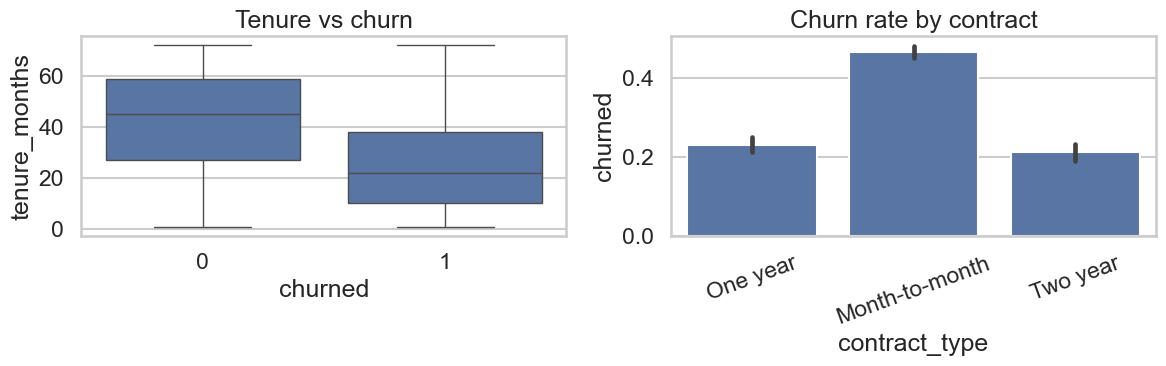

In [4]:
# Quick sanity: churn vs tenure / contract (evidence the CMO can feel)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="churned", y="tenure_months", ax=ax[0])
ax[0].set_title("Tenure vs churn")
sns.barplot(data=df, x="contract_type", y="churned", errorbar="ci", ax=ax[1])
ax[1].set_title("Churn rate by contract")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [5]:
TARGET = "churned"
ID_COL = "customer_id"
feature_cols = [c for c in df.columns if c not in (TARGET, ID_COL)]
X = df[feature_cols]
y = df[TARGET]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols), ("num", "passthrough", num_cols)]
)

clf = (
    xgb.XGBClassifier(
        n_estimators=250,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.85,
        reg_lambda=1.2,
        random_state=42,
        eval_metric="logloss",
        n_jobs=0,
    )
    if HAS_XGB
    else HistGradientBoostingClassifier(
        max_depth=5,
        learning_rate=0.06,
        max_iter=300,
        random_state=42,
    )
)

model = Pipeline(
    steps=[
        ("prep", pre),
        (
            "clf",
            clf,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
print("ROC-AUC", roc_auc_score(y_test, proba).round(3))
print("Average precision (PR-AUC)", average_precision_score(y_test, proba).round(3))
print("Brier score (lower is better)", brier_score_loss(y_test, proba).round(4))


ROC-AUC 0.802
Average precision (PR-AUC) 0.687
Brier score (lower is better) 0.1701


In [6]:
# Business-ish view: precision/recall at a fixed contact budget (top 15% risk)
k = int(0.15 * len(y_test))
idx = np.argsort(-proba)[:k]
prec_at_k = y_test.iloc[idx].mean()
print(f"Precision@15% ({k} customers)", round(float(prec_at_k), 3))
print("Baseline churn in test", round(float(y_test.mean()), 3))


Precision@15% (262 customers) 0.752
Baseline churn in test 0.352


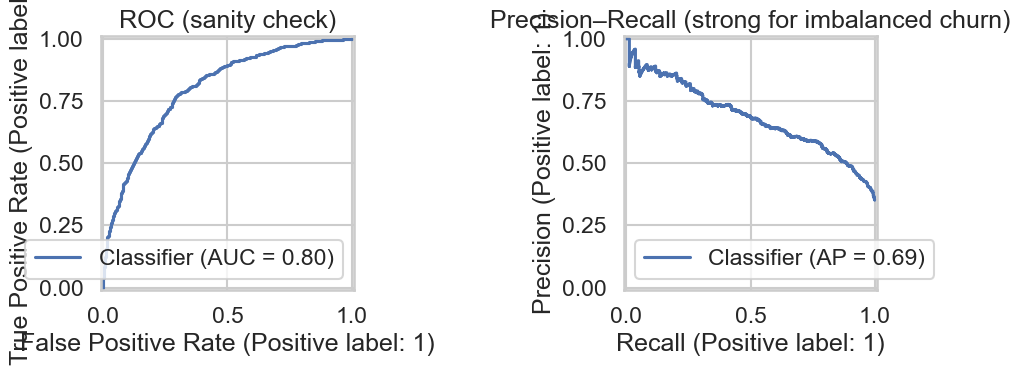

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[0])
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=ax[1])
ax[0].set_title("ROC (sanity check)")
ax[1].set_title("Precision–Recall (strong for imbalanced churn)")
plt.tight_layout()
plt.show()


In [8]:
# Permutation importance on held-out (more robust than raw gain for storytelling)
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, scoring="average_precision"
)
imp = pd.Series(result.importances_mean, index=feature_cols).sort_values(ascending=False)
display(imp.head(12))


tenure_months        0.180645
contract_type        0.096906
monthly_charges      0.032622
late_payments_6mo    0.018320
internet_service     0.014011
payment_method       0.013069
online_security      0.008356
total_charges        0.006704
support_calls_3mo    0.003068
multiple_lines       0.001683
phone_service        0.001162
streaming_tv         0.000978
dtype: float64

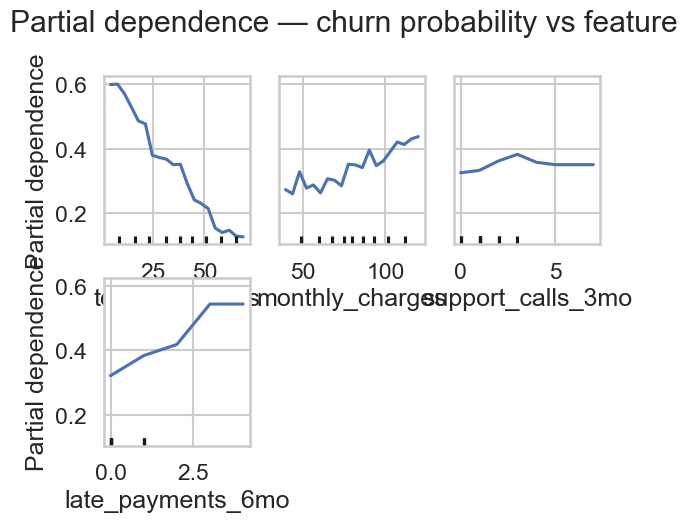

In [9]:
# Partial dependence on top numeric levers (evidence beyond a bar chart)
top_num = [c for c in ["tenure_months", "monthly_charges", "support_calls_3mo", "late_payments_6mo"] if c in num_cols]
if top_num:
    PartialDependenceDisplay.from_estimator(
        model, X_test, features=top_num, kind="average", grid_resolution=20
    )
    plt.suptitle("Partial dependence — churn probability vs feature", y=1.02)
    plt.show()


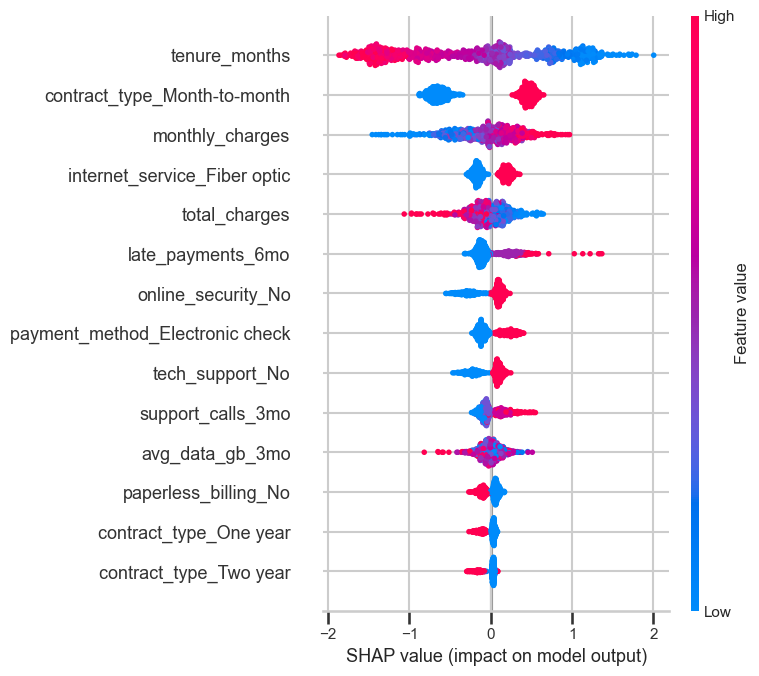

In [10]:
# SHAP (optional): explain a sample for the CMO conversation
try:
    import shap

    prep = model.named_steps["prep"]
    clf = model.named_steps["clf"]
    X_enc = prep.transform(X_test)
    # feature names after OHE
    cat_names = prep.named_transformers_["cat"].get_feature_names_out(cat_cols)
    feat_names = np.concatenate([cat_names, np.array(num_cols)])
    sample = slice(0, min(800, X_enc.shape[0]))
    if HAS_XGB:
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_enc[sample])
        shap.summary_plot(sv, X_enc[sample], feature_names=feat_names, max_display=14, show=True)
    else:
        print("SHAP tree summary skipped for fallback model (no XGBoost).")
except Exception as e:
    print("SHAP skipped:", e)


In [11]:
# Segment churners (stable alternative to KMeans warnings)
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import RobustScaler

ch = df[df["churned"] == 1].copy()

seg_feats = [
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "support_calls_3mo",
    "late_payments_6mo",
    "avg_data_gb_3mo",
]

X_seg = ch[seg_feats].apply(pd.to_numeric, errors="coerce")
X_seg = X_seg.replace([np.inf, -np.inf], np.nan)
X_seg = X_seg.fillna(X_seg.median(numeric_only=True)).fillna(0.0)

# robust scaling + clipping for stability
Z = RobustScaler().fit_transform(X_seg.astype(np.float64))
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
Z = np.clip(Z, -10, 10)

clusterer = AgglomerativeClustering(n_clusters=3, linkage="ward")
ch["segment"] = clusterer.fit_predict(Z)

summary = (
    ch.groupby("segment")[seg_feats + ["churned"]]
    .mean()
    .sort_values("monthly_charges")
)
display(summary)

,tenure_months,monthly_charges,total_charges,support_calls_3mo,late_payments_6mo,avg_data_gb_3mo,churned
segment,,,,,,,
0,19.720058,81.152114,1441.175837,1.418470,0.137085,27.732648,1.0
2,12.877358,84.839104,1047.809057,1.009434,1.297170,23.212665,1.0
1,46.430322,98.041194,4280.979005,1.133231,0.447167,22.570704,1.0


In [12]:
# Profile segments in plain language for the deck
for s in sorted(ch["segment"].unique()):
    sub = ch[ch["segment"] == s]
    print("\n=== Segment", s, "n=", len(sub), "===")
    print("Median tenure", sub["tenure_months"].median())
    print("Median monthly $", sub["monthly_charges"].median())
    print("Median support calls", sub["support_calls_3mo"].median())
    print("Share month-to-month", (sub["contract_type"] == "Month-to-month").mean().round(2))
    print("Share electronic check", (sub["payment_method"] == "Electronic check").mean().round(2))



=== Segment 0 n= 1386 ===
Median tenure 18.0
Median monthly $ 80.83
Median support calls 1.0
Share month-to-month 0.67
Share electronic check 0.38

=== Segment 1 n= 653 ===
Median tenure 46.0
Median monthly $ 99.79
Median support calls 1.0
Share month-to-month 0.83
Share electronic check 0.38

=== Segment 2 n= 424 ===
Median tenure 12.0
Median monthly $ 84.38
Median support calls 1.0
Share month-to-month 0.6
Share electronic check 0.41


## Takeaways (mirror these in `deliverables/exec_summary.md`)

1. **Contract + tenure** usually dominate — month-to-month, low tenure customers behave like "try-before-you-buy" churn.
2. **Billing friction** (electronic check, paperless) often clusters with involuntary/payment confusion churn.
3. **Service frustration** (support calls, late payments) marks a recoverable-with-care segment if contacted early.

**Next modeling step if budget appears:** uplift / causal incrementality — who is *saved* by an offer, not only who churns.


In [13]:
# --- CELL 1: Environment Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Set visual style for the CMO presentation
plt.style.use('ggplot')
%matplotlib inline

# --- CELL 2: Data Loading & Validation ---
# Path provided in the brief: datasets/case4_telecom_churn.csv
file_path = 'datasets/case4_telecom_churn.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
except FileNotFoundError:
    print(f"ERROR: File not found at {file_path}. Please check your directory structure.")
    # Creating a dummy df to prevent NameError if you want to test the logic
    df = pd.DataFrame() 

# --- CELL 3: Preprocessing (The 'Transparent' Box) ---
if not df.empty:
    le_dict = {}
    df_model = df.copy()
    
    # Selecting categorical features for encoding
    cat_cols = df.select_dtypes(include=['object']).columns.drop('customer_id')

    for col in cat_cols:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

    # Define Features and Target per schema
    X = df_model.drop(columns=['customer_id', 'churned'])
    y = df_model['churned']

    # Stratified split to maintain the ~36% base churn rate
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Preprocessing complete.")

# --- CELL 4: Modeling & CMO Evidence ---
if not df.empty:
    # Using Random Forest for better feature interpretation
    rf = RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        class_weight='balanced', 
        random_state=42
    )
    rf.fit(X_train, y_train)

    # Performance Reporting
    y_prob = rf.predict_proba(X_test)[:, 1]
    print(f"Model AUC-ROC: {roc_auc_score(y_test, y_prob):.2f}")
    print(classification_report(y_test, rf.predict(X_test)))

    # Feature Importance Visualization
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    importances.tail(10).plot(kind='barh', color='skyblue')
    plt.title('Top 10 Drivers of Churn (Evidence for CMO)')
    plt.xlabel('Relative Importance Score')
    plt.show()

ERROR: File not found at datasets/case4_telecom_churn.csv. Please check your directory structure.
